# Explore here

It's recommended to use this notebook for exploration purposes.

In [9]:
import os
from bs4 import BeautifulSoup
import requests
import time
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [10]:

#Paso 1-2: Descargando HTML
url = "https://en.wikipedia.org/wiki/List_of_Spotify_streaming_records"

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/141.0.0.0 Safari/537.36'
}

response = requests.get(url, headers=headers)

html_content = response.text

print(" Página descargada correctamente")
print(f"  Tamaño: {len(html_content)} caracteres")



 Página descargada correctamente
  Tamaño: 681165 caracteres


In [20]:
print("Transformando el HTML con BeautifulSoup")

# Crear objeto BeautifulSoup para analizar el HTML
soup = BeautifulSoup(html_content, 'html.parser')

# Buscar la tabla con clase "wikitable"
tabla = soup.find('table', {'class': 'wikitable'})

if tabla:
    print(" Tabla encontrada")
else:
    print(" No se encontró la tabla")
    exit()

# Convertir la tabla HTML a DataFrame
df = pd.read_html(str(tabla))[0]

print(f"Tabla convertida a DataFrame")
print(f"  Filas: {len(df)}")
print(f"  Columnas: {list(df.columns)}")
print()

# Mostrar las primeras 3 filas
print("Primeras 3 filas de la tabla:")
print(df.head(3))
print()

Transformando el HTML con BeautifulSoup
 Tabla encontrada
Tabla convertida a DataFrame
  Filas: 101
  Columnas: ['Rank', 'Song', 'Artist(s)', 'Streams (billions)', 'Release date', 'Ref.']

Primeras 3 filas de la tabla:
  Rank               Song                 Artist(s) Streams (billions)  \
0    1  "Blinding Lights"                The Weeknd              5.162   
1    2     "Shape of You"                Ed Sheeran              4.666   
2    3          "Starboy"  The Weeknd and Daft Punk              4.230   

        Release date Ref.  
0   29 November 2019  [1]  
1     6 January 2017  [2]  
2  21 September 2016  [3]  



/tmp/ipykernel_6590/115407251.py:16: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(str(tabla))[0]


In [21]:
if response.status_code == 200:
  print("La petición ha ido bien")
  soup = BeautifulSoup(response.text, "html.parser")
else:
  print("La petición ha ido mal")

La petición ha ido bien


In [22]:
#Analizando HTML y extrayendo tabla

try:
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/141.0.0.0 Safari/537.36'}
    respuesta = requests.get(url, headers=headers)
    html = respuesta.text
    
    tables = pd.read_html(html)
    print(f"-Se encontraron {len(tables)} tablas")
    
    df = tables[0]
    print("-Tabla extraída a DataFrame")
except Exception as e:
    print(f"Error al procesar HTML: {e}")
    exit()

-Se encontraron 27 tablas
-Tabla extraída a DataFrame


/tmp/ipykernel_6590/783546286.py:8: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


In [23]:
#Limpiar datos
df = df.dropna(how='all')  # Elimina filas vacías
df['Streams (billions)'] = df['Streams (billions)'].str.replace('$', '')  # Quita símbolos

In [24]:
df_clean = df.dropna() 
conn = sqlite3.connect("Spotify.db")

df_clean.to_sql("Mas Escuchados", conn, if_exists="replace", index=False)

cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM 'Mas Escuchados'")
print("Encontradas:", cursor.fetchone()[0])


conn.commit()
conn.close()

Encontradas: 99


Gráfica guardada como 'top10.png'


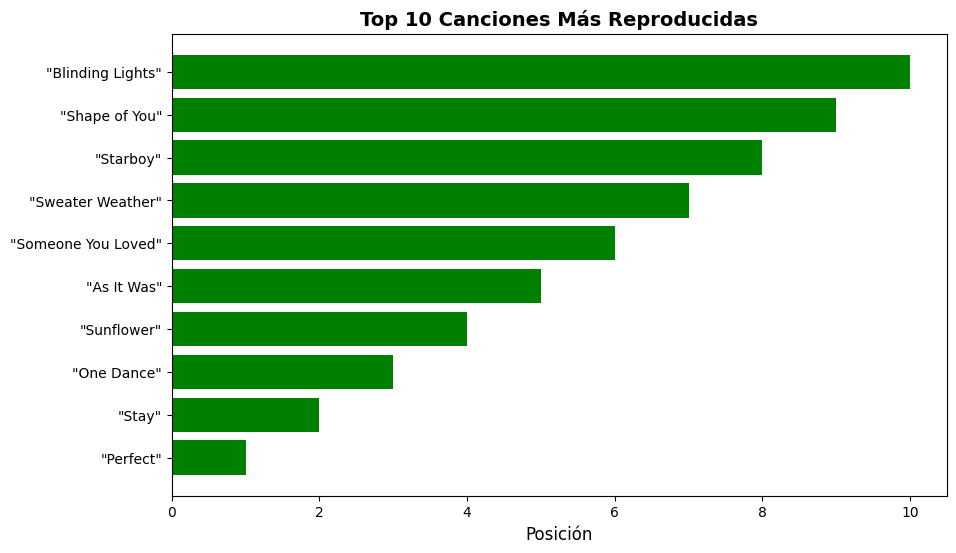

In [31]:
#GRAFICA

# Sacar el Top 10
top10 = df.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top10['Song'], range(10, 0, -1), color='green')
plt.xlabel('Posición', fontsize=12)
plt.title('Top 10 Canciones Más Reproducidas', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.savefig('top10.png', dpi=300, bbox_inches='tight')
print("Gráfica guardada como 'top10.png'")

# Mostrar
plt.show()
print()
 